In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
# Projection function
def projection(point, center, radius):
    """Projects a 2D point onto a closed disk."""
    diff = point - center
    dist = np.linalg.norm(diff)
    if dist <= radius:
        return point
    return center + (diff / dist) * radius

In [ ]:
# Main algorithm
def alternating_projections(start, A, B, tol=2e-6, iterations=50):
    """
    Finds a point in the intersection of two disks using
    the Alternating Projections algorithm.
    """
    path = [start]
    curr = start

    for _ in range(iterations):
        # Project onto Disk A
        p_a = projection(curr, A["center"], A["radius"])
        path.append(p_a)

        # Project onto Disk B
        p_b = projection(p_a, B["center"], B["radius"])
        path.append(p_b)

        # Check for convergence
        if np.linalg.norm(p_a - p_b) < tol:
            break
        curr = p_b

    return np.array(path)

In [55]:
# Problem Parameters
A = {"center": np.array([0, 0]), "radius": 1.0}
B = {"center": np.array([3, 0]), "radius": 2.05}
start_point = np.array([1.5, 2.0])

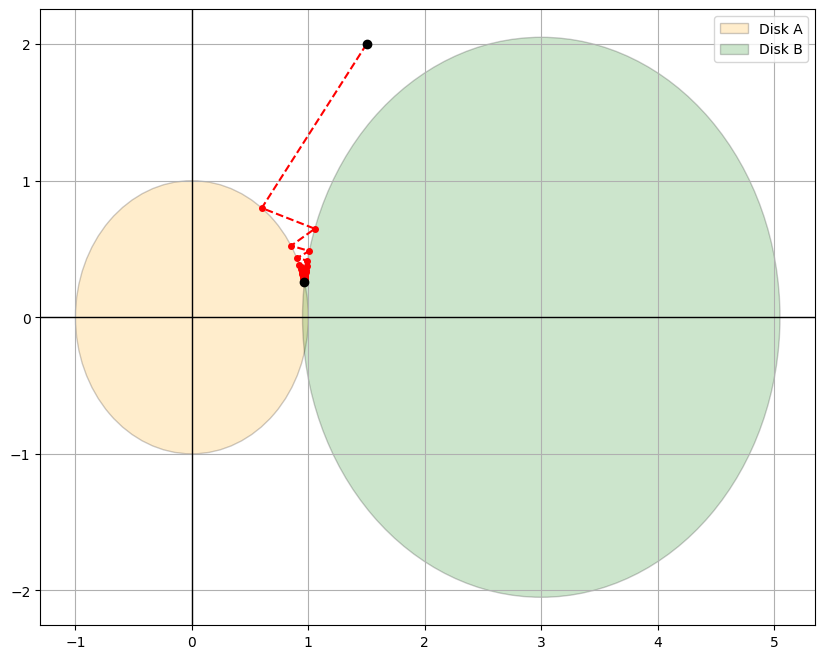

In [58]:
# Visualization
plt.figure(figsize=(10, 8))
ax = plt.gca()

circle1 = plt.Circle(A["center"], A["radius"], facecolor="orange", edgecolor="black", alpha=0.2, label="Disk A")
circle2 = plt.Circle(B["center"], B["radius"], facecolor="green", edgecolor="black", alpha=0.2, label="Disk B")
ax.add_patch(circle1)
ax.add_patch(circle2)

# Starting point
plt.scatter(start_point[0], start_point[1], color="black", zorder=5)

path = alternating_projections(start_point, A, B)

# Plot the path of projections
plt.plot(path[:, 0], path[:, 1], "--o", markersize=4, color="red")

# Final intersection point
plt.scatter(path[-1, 0], path[-1, 1], color="black", zorder=5)

plt.axhline(0, color="black", lw=1)
plt.axvline(0, color="black", lw=1)

plt.legend()
plt.grid(True)
plt.show()